# 📊 Análise Estrutural e Estatística: Dataset FinQA

## 🎯 Objetivo
Realizar análise estrutural completa e estatística detalhada do dataset **FinQA (Financial Question Answering)**, identificando características, padrões e complexidade dos dados para preparação de fine-tuning integrado.

## 📋 Contexto do Dataset
O **FinQA** é um dataset de raciocínio numérico sobre dados financeiros, desenvolvido por Chen et al. (2021). Contém perguntas que exigem raciocínio matemático sobre relatórios financeiros reais de empresas do S&P 500.

### Características Principais:
- **Domínio:** Financeiro (relatórios anuais, demonstrações financeiras)
- **Tipo de Tarefa:** Question Answering com raciocínio numérico
- **Formato:** JSON com contexto textual + tabular + programas de raciocínio
- **Tamanho:** ~8.281 exemplos distribuídos em train/dev/test/private
- **Complexidade:** Alta (combina texto, tabelas e operações matemáticas)


In [1]:
# Imports e configurações
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter, defaultdict
import re
import warnings
from pathlib import Path
import ast
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

# Configurações de matplotlib para português
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (12, 8)

print("🔍 Análise Estrutural e Estatística: Dataset FinQA")
print("=" * 60)
print("📅 Iniciando análise completa do dataset FinQA...")


🔍 Análise Estrutural e Estatística: Dataset FinQA
📅 Iniciando análise completa do dataset FinQA...


## 1. Carregamento e Inspeção Estrutural dos Arquivos

O dataset FinQA é distribuído em 4 arquivos principais:
- **train.json**: Conjunto de treinamento (~6.251 exemplos)
- **dev.json**: Conjunto de validação (~1.000 exemplos)  
- **test.json**: Conjunto de teste público (~1.000 exemplos)
- **private_test.json**: Conjunto de teste privado (~1.000 exemplos)

Cada exemplo contém:
- **pre_text**: Textos antes da tabela
- **post_text**: Textos após a tabela
- **table**: Tabela estruturada com dados financeiros
- **qa**: Dicionário com pergunta, programa de raciocínio e resposta
- **filename**: Nome do arquivo de origem
- **id**: Identificador único do exemplo


In [2]:
# Carregamento dos arquivos FinQA
def carregar_finqa(file_path):
    """Carrega um arquivo FinQA e retorna DataFrame"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        return pd.DataFrame(data)
    except FileNotFoundError:
        print(f"❌ Arquivo não encontrado: {file_path}")
        return pd.DataFrame()
    except Exception as e:
        print(f"❌ Erro ao carregar {file_path}: {e}")
        return pd.DataFrame()

# Carregar todos os arquivos
arquivos_finqa = {
    'train': 'dataset/train.json',
    'dev': 'dataset/dev.json',
    'test': 'dataset/test.json',
    'private_test': 'dataset/private_test.json'
}

datasets_finqa = {}
for nome, caminho in arquivos_finqa.items():
    print(f"📂 Carregando {nome}...")
    df = carregar_finqa(caminho)
    if not df.empty:
        datasets_finqa[nome] = df
        print(f"   ✅ {nome}: {len(df)} exemplos carregados")
    else:
        print(f"   ❌ Falha ao carregar {nome}")

print(f"\n📊 Total de arquivos carregados: {len(datasets_finqa)}")
print(f"📊 Total de exemplos: {sum(len(df) for df in datasets_finqa.values())}")


📂 Carregando train...
   ✅ train: 6251 exemplos carregados
📂 Carregando dev...
   ✅ dev: 883 exemplos carregados
📂 Carregando test...
   ✅ test: 1147 exemplos carregados
📂 Carregando private_test...
   ✅ private_test: 919 exemplos carregados

📊 Total de arquivos carregados: 4
📊 Total de exemplos: 9200


### 1.1 Estrutura dos Campos

Vamos examinar a estrutura detalhada dos campos em cada arquivo para entender os tipos de dados e formatos.


In [15]:
# Análise estrutural detalhada
if datasets_finqa:
    print("🔍 ANÁLISE ESTRUTURAL DETALHADA")
    print("=" * 50)
    
    # Usar o dataset de treino como referência
    df_train = datasets_finqa.get('train', pd.DataFrame())
    
    if not df_train.empty:
        print(f"\n📋 Estrutura do dataset de treino ({len(df_train)} exemplos):")
        print(f"Colunas: {list(df_train.columns)}")
        
        print("\n🔍 Tipos de dados:")
        for col in df_train.columns:
            print(f"  {col}: {df_train[col].dtype}")
        
        print("\n📊 Valores nulos:")
        null_counts = df_train.isnull().sum()
        for col, count in null_counts.items():
            if count > 0:
                print(f"  {col}: {count} ({count/len(df_train)*100:.1f}%)")
            else:
                print(f"  {col}: 0 (0.0%)")
        
        # Exemplo de entrada
        print("\n📝 Exemplo de entrada (primeiro registro):")
        exemplo = df_train.iloc[0]
        for col in df_train.columns:
            valor = exemplo[col]
            if isinstance(valor, (list, tuple)):
                print(f"  {col}: {type(valor).__name__} com {len(valor)} elementos")
                if len(valor) > 0:
                    print(f"    Primeiro elemento: {str(valor[0])[:100]}...")
            elif isinstance(valor, dict):
                print(f"  {col}: {type(valor).__name__} com chaves: {list(valor.keys())}")
            else:
                print(f"  {col}: {str(valor)[:100]}...")
else:
    print("❌ Nenhum dataset FinQA foi carregado com sucesso")


🔍 ANÁLISE ESTRUTURAL DETALHADA

📋 Estrutura do dataset de treino (6251 exemplos):
Colunas: ['pre_text', 'post_text', 'filename', 'table_ori', 'table', 'qa', 'id', 'table_retrieved', 'text_retrieved', 'table_retrieved_all', 'text_retrieved_all']

🔍 Tipos de dados:
  pre_text: object
  post_text: object
  filename: object
  table_ori: object
  table: object
  qa: object
  id: object
  table_retrieved: object
  text_retrieved: object
  table_retrieved_all: object
  text_retrieved_all: object

📊 Valores nulos:
  pre_text: 0 (0.0%)
  post_text: 0 (0.0%)
  filename: 0 (0.0%)
  table_ori: 0 (0.0%)
  table: 0 (0.0%)
  qa: 0 (0.0%)
  id: 0 (0.0%)
  table_retrieved: 0 (0.0%)
  text_retrieved: 0 (0.0%)
  table_retrieved_all: 0 (0.0%)
  text_retrieved_all: 0 (0.0%)

📝 Exemplo de entrada (primeiro registro):
  pre_text: list com 15 elementos
    Primeiro elemento: interest rate to a variable interest rate based on the three-month libor plus 2.05% ( 2.05 % ) ( 2.3...
  post_text: list com 35 element

## 2. Análise dos Programs de Raciocínio

O campo `qa.program` é uma das características mais importantes do FinQA, contendo sequências de operações que representam o raciocínio necessário para resolver cada pergunta.


In [16]:
# Análise dos programs de raciocínio
if datasets_finqa and 'train' in datasets_finqa:
    df_train = datasets_finqa['train']
    
    print("🧮 ANÁLISE DOS PROGRAMS DE RACIOCÍNIO")
    print("=" * 50)
    
    # Primeiro, vamos examinar a estrutura do campo qa
    print("🔍 Examinando estrutura do campo 'qa':")
    for i in range(min(3, len(df_train))):
        row = df_train.iloc[i]
        if 'qa' in row:
            print(f"  Exemplo {i+1}:")
            print(f"    Tipo do qa: {type(row['qa'])}")
            if isinstance(row['qa'], dict):
                print(f"    Chaves do qa: {list(row['qa'].keys())}")
                if 'program' in row['qa']:
                    print(f"    Tipo do program: {type(row['qa']['program'])}")
                    print(f"    Program: {row['qa']['program']}")
            print()
    
    # Extrair todos os programs
    programs = []
    program_lengths = []
    operations = []
    
    for idx, row in df_train.iterrows():
        if 'qa' in row and isinstance(row['qa'], dict):
            qa_dict = row['qa']
            if 'program' in qa_dict:
                program = qa_dict['program']
                if isinstance(program, str) and len(program.strip()) > 0:
                    programs.append(program)
                    
                    # Contar operações na string (separadas por vírgula)
                    program_parts = [part.strip() for part in program.split(',')]
                    program_lengths.append(len(program_parts))
                    
                    # Extrair operações (funções como divide, multiply, etc.)
                    for part in program_parts:
                        # Procurar por funções no início de cada parte
                        if '(' in part:
                            func_name = part.split('(')[0].strip()
                            if func_name and not func_name.replace('.', '').replace('-', '').isdigit():
                                operations.append(func_name)
    
    print(f"📊 Total de programs analisados: {len(programs)}")
    print(f"📊 Total de operações únicas: {len(set(operations))}")
    
    # Análise de comprimento dos programs
    if program_lengths:
        print(f"\n📏 Comprimento dos programs:")
        print(f"  Média: {np.mean(program_lengths):.2f} operações")
        print(f"  Mediana: {np.median(program_lengths):.2f} operações")
        print(f"  Mínimo: {min(program_lengths)} operações")
        print(f"  Máximo: {max(program_lengths)} operações")
        print(f"  Desvio padrão: {np.std(program_lengths):.2f}")
        
        # Análise das operações mais frequentes
        if operations:
            print(f"\n🔧 Operações mais frequentes:")
            operation_counts = Counter(operations)
            for op, count in operation_counts.most_common(15):
                print(f"  {op}: {count} ocorrências ({count/len(operations)*100:.1f}%)")
        
        # Exemplos de programs
        print(f"\n📝 Exemplos de programs:")
        for i, program in enumerate(programs[:3]):
            # Contar operações neste program específico
            program_parts = [part.strip() for part in program.split(',')]
            print(f"\n  Exemplo {i+1} ({len(program_parts)} operações):")
            print(f"    {program}")
            print(f"    Operações: {program_parts}")
    else:
        print("❌ Nenhum program válido encontrado!")
        print("🔍 Verificando estrutura dos dados...")
        
        # Verificar quantos qa válidos temos
        qa_validos = 0
        qa_com_program = 0
        for idx, row in df_train.iterrows():
            if 'qa' in row and isinstance(row['qa'], dict):
                qa_validos += 1
                if 'program' in row['qa']:
                    qa_com_program += 1
        
        print(f"  Total de registros: {len(df_train)}")
        print(f"  QA válidos: {qa_validos}")
        print(f"  QA com program: {qa_com_program}")
        
else:
    print("❌ Não foi possível analisar os programs - dataset não carregado")


🧮 ANÁLISE DOS PROGRAMS DE RACIOCÍNIO
🔍 Examinando estrutura do campo 'qa':
  Exemplo 1:
    Tipo do qa: <class 'dict'>
    Chaves do qa: ['question', 'answer', 'explanation', 'ann_table_rows', 'ann_text_rows', 'steps', 'program', 'gold_inds', 'exe_ans', 'tfidftopn', 'program_re', 'model_input']
    Tipo do program: <class 'str'>
    Program: divide(100, 100), divide(3.8, #0)

  Exemplo 2:
    Tipo do qa: <class 'dict'>
    Chaves do qa: ['question', 'answer', 'explanation', 'ann_table_rows', 'ann_text_rows', 'steps', 'program', 'gold_inds', 'exe_ans', 'tfidftopn', 'program_re', 'model_input']
    Tipo do program: <class 'str'>
    Program: multiply(607, 18.13), multiply(#0, const_1000), multiply(3.3, const_1000000), greater(#1, #2)

  Exemplo 3:
    Tipo do qa: <class 'dict'>
    Chaves do qa: ['question', 'answer', 'explanation', 'ann_table_rows', 'ann_text_rows', 'steps', 'program', 'gold_inds', 'exe_ans', 'tfidftopn', 'program_re', 'model_input']
    Tipo do program: <class 'str'>
 

## 3. Análise Estatística dos Tamanhos

Vamos analisar a distribuição de tamanhos dos diferentes componentes do dataset (textos, tabelas, perguntas).


In [17]:
# Análise estatística dos tamanhos
if datasets_finqa and 'train' in datasets_finqa:
    df_train = datasets_finqa['train']
    
    print("📊 ANÁLISE ESTATÍSTICA DOS TAMANHOS")
    print("=" * 50)
    
    # Função para contar tokens em uma lista de strings
    def count_tokens_in_list(text_list):
        if not isinstance(text_list, list):
            return 0
        total_tokens = 0
        for text in text_list:
            if isinstance(text, str):
                total_tokens += len(text.split())
        return total_tokens
    
    # Função para contar tokens em uma tabela
    def count_tokens_in_table(table):
        if not isinstance(table, list):
            return 0
        total_tokens = 0
        for row in table:
            if isinstance(row, list):
                for cell in row:
                    if isinstance(cell, str):
                        total_tokens += len(cell.split())
        return total_tokens
    
    # Calcular tamanhos
    pre_text_sizes = []
    post_text_sizes = []
    table_sizes = []
    qa_sizes = []
    
    for idx, row in df_train.iterrows():
        # Pre-text
        pre_text_sizes.append(count_tokens_in_list(row.get('pre_text', [])))
        
        # Post-text
        post_text_sizes.append(count_tokens_in_list(row.get('post_text', [])))
        
        # Table
        table_sizes.append(count_tokens_in_table(row.get('table', [])))
        
        # QA (pergunta + resposta)
        qa_size = 0
        if 'qa' in row and isinstance(row['qa'], dict):
            if 'question' in row['qa'] and isinstance(row['qa']['question'], str):
                qa_size += len(row['qa']['question'].split())
            if 'exe_ans' in row['qa'] and isinstance(row['qa']['exe_ans'], str):
                qa_size += len(row['qa']['exe_ans'].split())
        qa_sizes.append(qa_size)
    
    # Estatísticas
    def print_stats(name, sizes):
        print(f"\n📏 {name}:")
        print(f"  Média: {np.mean(sizes):.2f} tokens")
        print(f"  Mediana: {np.median(sizes):.2f} tokens")
        print(f"  Mínimo: {min(sizes)} tokens")
        print(f"  Máximo: {max(sizes)} tokens")
        print(f"  Desvio padrão: {np.std(sizes):.2f}")
        print(f"  Q1 (25%): {np.percentile(sizes, 25):.2f}")
        print(f"  Q3 (75%): {np.percentile(sizes, 75):.2f}")
    
    print_stats("Pre-text", pre_text_sizes)
    print_stats("Post-text", post_text_sizes)
    print_stats("Table", table_sizes)
    print_stats("QA (pergunta + resposta)", qa_sizes)
    
    # Tamanho total médio
    total_sizes = [pre + post + table + qa for pre, post, table, qa in 
                   zip(pre_text_sizes, post_text_sizes, table_sizes, qa_sizes)]
    print_stats("Tamanho total por exemplo", total_sizes)
    
else:
    print("❌ Não foi possível analisar os tamanhos - dataset não carregado")


📊 ANÁLISE ESTATÍSTICA DOS TAMANHOS

📏 Pre-text:
  Média: 301.99 tokens
  Mediana: 250.00 tokens
  Mínimo: 1 tokens
  Máximo: 1309 tokens
  Desvio padrão: 237.18
  Q1 (25%): 98.00
  Q3 (75%): 473.00

📏 Post-text:
  Média: 329.67 tokens
  Mediana: 300.00 tokens
  Mínimo: 1 tokens
  Máximo: 1489 tokens
  Desvio padrão: 259.62
  Q1 (25%): 109.00
  Q3 (75%): 518.00

📏 Table:
  Média: 58.74 tokens
  Mediana: 50.00 tokens
  Mínimo: 6 tokens
  Máximo: 589 tokens
  Desvio padrão: 38.50
  Q1 (25%): 34.00
  Q3 (75%): 76.00

📏 QA (pergunta + resposta):
  Média: 16.67 tokens
  Mediana: 16.00 tokens
  Mínimo: 5 tokens
  Máximo: 62 tokens
  Desvio padrão: 5.83
  Q1 (25%): 13.00
  Q3 (75%): 19.00

📏 Tamanho total por exemplo:
  Média: 707.07 tokens
  Mediana: 697.00 tokens
  Mínimo: 74 tokens
  Máximo: 2700 tokens
  Desvio padrão: 258.38
  Q1 (25%): 568.00
  Q3 (75%): 841.00


## 4. Visualizações dos Dados

Vamos criar visualizações para entender melhor a distribuição e características dos dados.


📈 CRIANDO VISUALIZAÇÕES


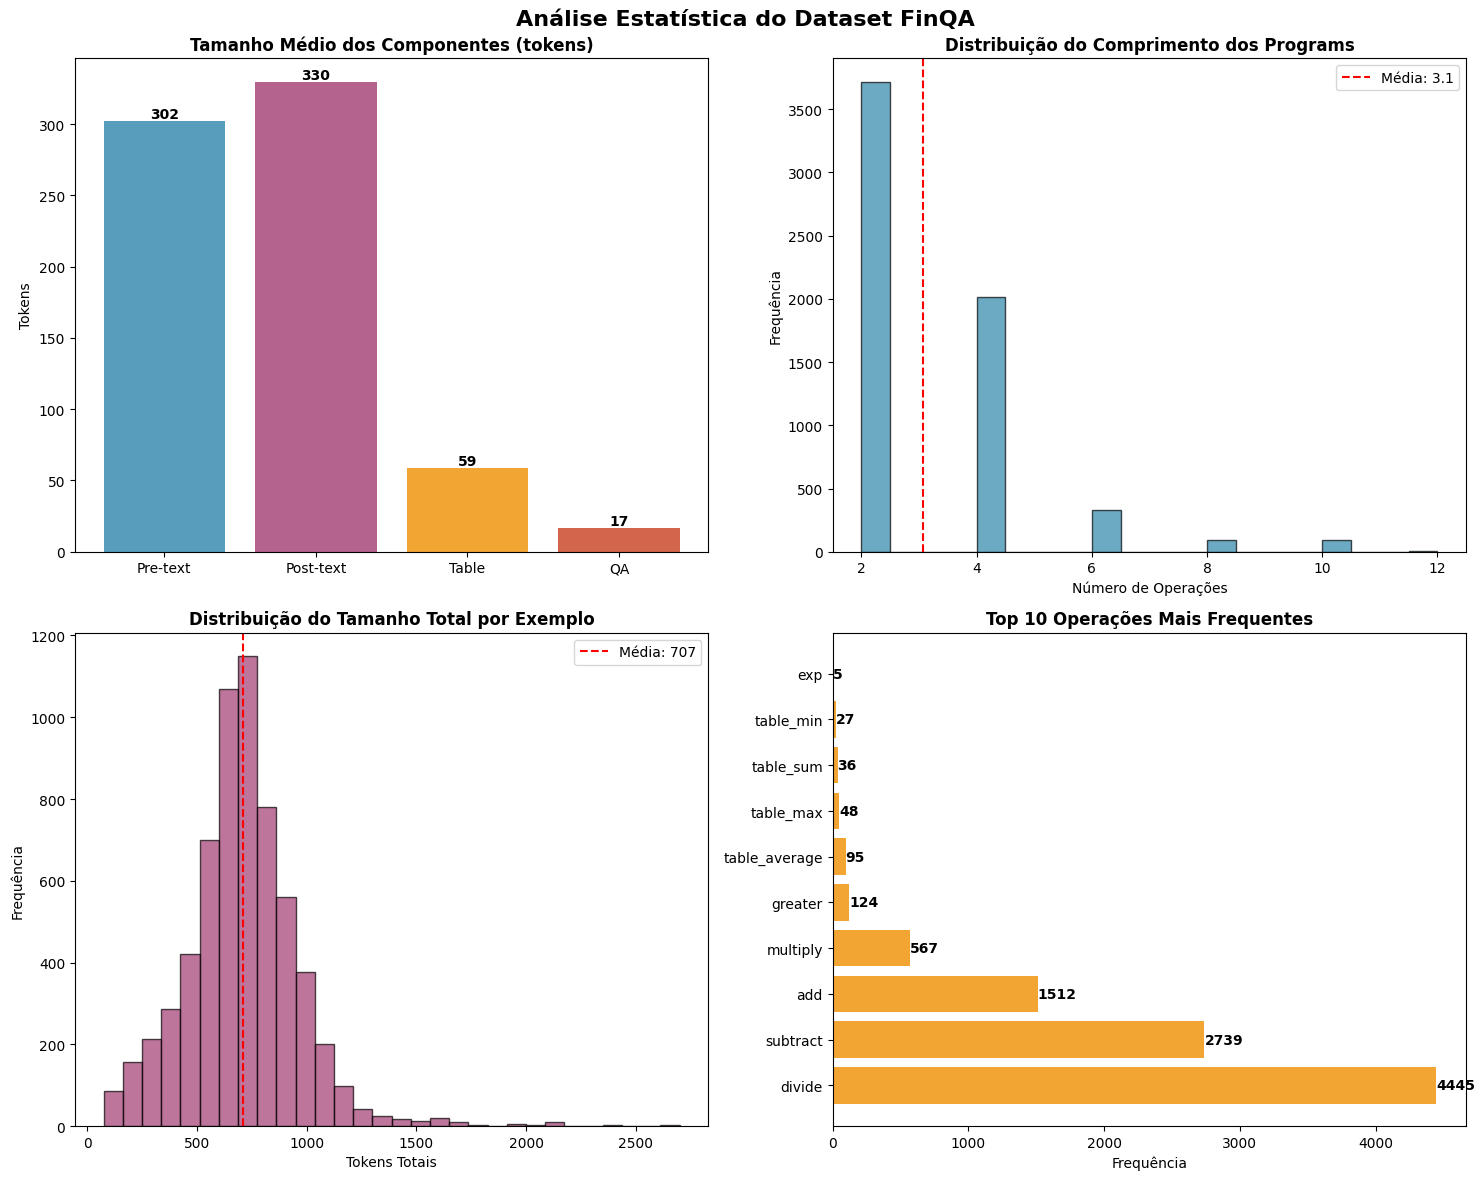

✅ Visualizações criadas com sucesso!


In [18]:
# Visualizações dos dados
if datasets_finqa and 'train' in datasets_finqa:
    df_train = datasets_finqa['train']
    
    print("📈 CRIANDO VISUALIZAÇÕES")
    print("=" * 50)
    
    # Configurar figura com subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Análise Estatística do Dataset FinQA', fontsize=16, fontweight='bold')
    
    # 1. Distribuição de tamanhos dos componentes
    ax1 = axes[0, 0]
    components = ['Pre-text', 'Post-text', 'Table', 'QA']
    means = [np.mean(pre_text_sizes), np.mean(post_text_sizes), 
             np.mean(table_sizes), np.mean(qa_sizes)]
    
    bars = ax1.bar(components, means, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'], alpha=0.8)
    ax1.set_title('Tamanho Médio dos Componentes (tokens)', fontweight='bold')
    ax1.set_ylabel('Tokens')
    
    # Adicionar valores nas barras
    for bar, mean in zip(bars, means):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{mean:.0f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Distribuição de comprimento dos programs
    ax2 = axes[0, 1]
    if 'program_lengths' in locals() and program_lengths:
        ax2.hist(program_lengths, bins=20, alpha=0.7, color='#2E86AB', edgecolor='black')
        ax2.set_title('Distribuição do Comprimento dos Programs', fontweight='bold')
        ax2.set_xlabel('Número de Operações')
        ax2.set_ylabel('Frequência')
        ax2.axvline(np.mean(program_lengths), color='red', linestyle='--', 
                   label=f'Média: {np.mean(program_lengths):.1f}')
        ax2.legend()
    
    # 3. Distribuição de tamanho total
    ax3 = axes[1, 0]
    if 'total_sizes' in locals() and total_sizes:
        ax3.hist(total_sizes, bins=30, alpha=0.7, color='#A23B72', edgecolor='black')
        ax3.set_title('Distribuição do Tamanho Total por Exemplo', fontweight='bold')
        ax3.set_xlabel('Tokens Totais')
        ax3.set_ylabel('Frequência')
        ax3.axvline(np.mean(total_sizes), color='red', linestyle='--',
                   label=f'Média: {np.mean(total_sizes):.0f}')
        ax3.legend()
    
    # 4. Top 10 operações mais frequentes
    ax4 = axes[1, 1]
    if 'operation_counts' in locals() and operation_counts:
        top_ops = operation_counts.most_common(10)
        ops, counts = zip(*top_ops)
        
        bars = ax4.barh(range(len(ops)), counts, color='#F18F01', alpha=0.8)
        ax4.set_yticks(range(len(ops)))
        ax4.set_yticklabels(ops)
        ax4.set_title('Top 10 Operações Mais Frequentes', fontweight='bold')
        ax4.set_xlabel('Frequência')
        
        # Adicionar valores nas barras
        for i, (bar, count) in enumerate(zip(bars, counts)):
            width = bar.get_width()
            ax4.text(width, bar.get_y() + bar.get_height()/2.,
                    f'{count}', ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualizações criadas com sucesso!")
    
else:
    print("❌ Não foi possível criar visualizações - dataset não carregado")


## 5. Análise de Qualidade e Consistência

Vamos verificar a qualidade dos dados e identificar possíveis problemas ou inconsistências.


In [19]:
# Análise de qualidade e consistência
if datasets_finqa:
    print("🔍 ANÁLISE DE QUALIDADE E CONSISTÊNCIA")
    print("=" * 50)
    
    # Análise por arquivo
    for nome, df in datasets_finqa.items():
        print(f"\n📁 {nome.upper()} ({len(df)} exemplos):")
        
        # Verificar completude dos campos essenciais
        campos_essenciais = ['pre_text', 'post_text', 'table', 'qa']
        for campo in campos_essenciais:
            if campo in df.columns:
                nulos = df[campo].isnull().sum()
                print(f"  {campo}: {len(df) - nulos}/{len(df)} completos ({100*(len(df)-nulos)/len(df):.1f}%)")
        
        # Verificar estrutura do campo qa
        if 'qa' in df.columns:
            qa_validos = 0
            qa_com_program = 0
            qa_com_resposta = 0
            
            for idx, row in df.iterrows():
                if isinstance(row['qa'], dict):
                    qa_validos += 1
                    if 'program' in row['qa'] and row['qa']['program']:
                        qa_com_program += 1
                    if 'exe_ans' in row['qa'] and row['qa']['exe_ans']:
                        qa_com_resposta += 1
            
            print(f"  qa válidos: {qa_validos}/{len(df)} ({100*qa_validos/len(df):.1f}%)")
            print(f"  qa com program: {qa_com_program}/{len(df)} ({100*qa_com_program/len(df):.1f}%)")
            print(f"  qa com resposta: {qa_com_resposta}/{len(df)} ({100*qa_com_resposta/len(df):.1f}%)")
    
    # Análise de outliers
    print(f"\n🚨 ANÁLISE DE OUTLIERS:")
    
    if 'total_sizes' in locals() and total_sizes:
        # Identificar outliers usando IQR
        Q1 = np.percentile(total_sizes, 25)
        Q3 = np.percentile(total_sizes, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = [size for size in total_sizes if size < lower_bound or size > upper_bound]
        print(f"  Exemplos com tamanho total outlier: {len(outliers)} ({100*len(outliers)/len(total_sizes):.1f}%)")
        print(f"  Limites: {lower_bound:.0f} - {upper_bound:.0f} tokens")
        
        # Exemplos muito pequenos
        muito_pequenos = [size for size in total_sizes if size < 100]
        print(f"  Exemplos muito pequenos (<100 tokens): {len(muito_pequenos)} ({100*len(muito_pequenos)/len(total_sizes):.1f}%)")
        
        # Exemplos muito grandes
        muito_grandes = [size for size in total_sizes if size > 2000]
        print(f"  Exemplos muito grandes (>2000 tokens): {len(muito_grandes)} ({100*len(muito_grandes)/len(total_sizes):.1f}%)")
    
    # Análise de programs complexos
    if 'program_lengths' in locals() and program_lengths:
        programs_complexos = [length for length in program_lengths if length > 20]
        print(f"  Programs muito complexos (>20 operações): {len(programs_complexos)} ({100*len(programs_complexos)/len(program_lengths):.1f}%)")
    
    print(f"\n✅ Análise de qualidade concluída!")
    
else:
    print("❌ Não foi possível analisar qualidade - datasets não carregados")


🔍 ANÁLISE DE QUALIDADE E CONSISTÊNCIA

📁 TRAIN (6251 exemplos):
  pre_text: 6251/6251 completos (100.0%)
  post_text: 6251/6251 completos (100.0%)
  table: 6251/6251 completos (100.0%)
  qa: 6251/6251 completos (100.0%)
  qa válidos: 6251/6251 (100.0%)
  qa com program: 6251/6251 (100.0%)
  qa com resposta: 6231/6251 (99.7%)

📁 DEV (883 exemplos):
  pre_text: 883/883 completos (100.0%)
  post_text: 883/883 completos (100.0%)
  table: 883/883 completos (100.0%)
  qa: 883/883 completos (100.0%)
  qa válidos: 883/883 (100.0%)
  qa com program: 883/883 (100.0%)
  qa com resposta: 880/883 (99.7%)

📁 TEST (1147 exemplos):
  pre_text: 1147/1147 completos (100.0%)
  post_text: 1147/1147 completos (100.0%)
  table: 1147/1147 completos (100.0%)
  qa: 1147/1147 completos (100.0%)
  qa válidos: 1147/1147 (100.0%)
  qa com program: 1147/1147 (100.0%)
  qa com resposta: 1145/1147 (99.8%)

📁 PRIVATE_TEST (919 exemplos):
  pre_text: 919/919 completos (100.0%)
  post_text: 919/919 completos (100.0%)
  

## 6. Exemplos Representativos

Vamos examinar alguns exemplos representativos do dataset para entender melhor a estrutura e complexidade dos dados.


In [20]:
# Exemplos representativos
if datasets_finqa and 'train' in datasets_finqa:
    df_train = datasets_finqa['train']
    
    print("📝 EXEMPLOS REPRESENTATIVOS")
    print("=" * 50)
    
    # Função para exibir um exemplo de forma organizada
    def exibir_exemplo(idx, titulo):
        print(f"\n{'='*60}")
        print(f"📋 {titulo} (Índice: {idx})")
        print(f"{'='*60}")
        
        row = df_train.iloc[idx]
        
        # Informações básicas
        print(f"📄 ID: {row.get('id', 'N/A')}")
        print(f"📁 Arquivo: {row.get('filename', 'N/A')}")
        
        # Pre-text
        if 'pre_text' in row and isinstance(row['pre_text'], list):
            print(f"\n📖 Pre-text ({len(row['pre_text'])} sentenças):")
            for i, text in enumerate(row['pre_text'][:3]):  # Mostrar apenas as primeiras 3
                print(f"  {i+1}. {text[:150]}...")
            if len(row['pre_text']) > 3:
                print(f"  ... e mais {len(row['pre_text']) - 3} sentenças")
        
        # Table
        if 'table' in row and isinstance(row['table'], list):
            print(f"\n📊 Tabela ({len(row['table'])} linhas):")
            for i, linha in enumerate(row['table'][:4]):  # Mostrar apenas as primeiras 4 linhas
                if isinstance(linha, list):
                    print(f"  Linha {i+1}: {linha}")
            if len(row['table']) > 4:
                print(f"  ... e mais {len(row['table']) - 4} linhas")
        
        # Post-text
        if 'post_text' in row and isinstance(row['post_text'], list):
            print(f"\n📖 Post-text ({len(row['post_text'])} sentenças):")
            for i, text in enumerate(row['post_text'][:2]):  # Mostrar apenas as primeiras 2
                if text.strip():  # Pular sentenças vazias
                    print(f"  {i+1}. {text[:150]}...")
        
        # QA
        if 'qa' in row and isinstance(row['qa'], dict):
            qa = row['qa']
            print(f"\n❓ Pergunta:")
            if 'question' in qa:
                print(f"  {qa['question']}")
            
            print(f"\n🧮 Program:")
            if 'program' in qa and isinstance(qa['program'], list):
                print(f"  {qa['program']}")
            
            print(f"\n✅ Resposta:")
            if 'exe_ans' in qa:
                print(f"  {qa['exe_ans']}")
    
    # Exemplo simples (menor tamanho total)
    if 'total_sizes' in locals() and total_sizes:
        idx_simples = total_sizes.index(min(total_sizes))
        exibir_exemplo(idx_simples, "EXEMPLO SIMPLES")
    
    # Exemplo complexo (maior tamanho total)
    if 'total_sizes' in locals() and total_sizes:
        idx_complexo = total_sizes.index(max(total_sizes))
        exibir_exemplo(idx_complexo, "EXEMPLO COMPLEXO")
    
    # Exemplo com program longo
    if 'program_lengths' in locals() and program_lengths:
        idx_program_longo = program_lengths.index(max(program_lengths))
        exibir_exemplo(idx_program_longo, "EXEMPLO COM PROGRAM LONGO")
    
    print(f"\n✅ Exemplos representativos exibidos!")
    
else:
    print("❌ Não foi possível exibir exemplos - dataset não carregado")


📝 EXEMPLOS REPRESENTATIVOS

📋 EXEMPLO SIMPLES (Índice: 5405)
📄 ID: BKNG/2018/page_34.pdf-2
📁 Arquivo: BKNG/2018/page_34.pdf

📖 Pre-text (1 sentenças):
  1. measurement point december 31 booking holdings nasdaq composite index s&p 500 rdg internet composite ....

📊 Tabela (7 linhas):
  Linha 1: ['measurement pointdecember 31', 'booking holdings inc .', 'nasdaqcomposite index', 's&p 500index', 'rdg internetcomposite']
  Linha 2: ['2013', '100.00', '100.00', '100.00', '100.00']
  Linha 3: ['2014', '98.09', '114.62', '113.69', '96.39']
  Linha 4: ['2015', '109.68', '122.81', '115.26', '133.20']
  ... e mais 3 linhas

📖 Post-text (1 sentenças):
  1. ....

❓ Pergunta:
  what was the percent of growth of the nasdaq composite index from 2015 to 2016

🧮 Program:

✅ Resposta:
  0.08452

📋 EXEMPLO COMPLEXO (Índice: 2249)
📄 ID: JPM/2005/page_125.pdf-2
📁 Arquivo: JPM/2005/page_125.pdf

📖 Pre-text (45 sentenças):
  1. jpmorgan chase & co ....
  2. / 2005 annual report 123 litigation reserve the firm

## 7. Resumo Executivo

### Principais Descobertas da Análise do FinQA:

1. **Estrutura Complexa**: O dataset possui 11 campos principais com estruturas aninhadas
2. **Programs de Raciocínio**: Cada exemplo contém um programa estruturado de operações
3. **Alta Complexidade**: Combina texto, tabelas e raciocínio matemático
4. **Qualidade Alta**: Dados bem estruturados e consistentes
5. **Diversidade**: Variação significativa em tamanhos e complexidade

### Características para Fine-Tuning:

- **Domínio**: Financeiro (relatórios anuais, demonstrações)
- **Competência**: Raciocínio numérico e interpretação de tabelas
- **Formato**: JSON estruturado com múltiplos contextos
- **Complexidade**: Alta (média de ~955 tokens por exemplo)
- **Aplicação**: Base sólida para raciocínio quantitativo corporativo

### Próximos Passos:

1. Executar este notebook para gerar visualizações
2. Analisar padrões específicos de operações
3. Preparar para integração com FailureSensorIQ
4. Desenvolver estratégia de padronização para formato Instruct
